In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from sklearn import model_selection
from sklearn.model_selection import train_test_split, cross_val_score, KFold

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

In [2]:
df = pd.read_excel("sipri_data.xlsx", sheet_name="GPR_Index_Long")

df.head()

,country,year,avg_gpr_index,avg_%_gdp_lagged_1_year
0,Belgium,2022,0.49,0.011723
1,Denmark,2022,0.09,0.020122
2,Finland,2022,0.23,0.020089
3,France,2022,0.92,0.019482
4,Germany,2022,1.25,0.015033


Note that we only have Geopolitical Risk Index Scores for 18 European countries. Using each year of the dataset allows for more datapoints across the timespan of the war.

In [3]:
X = df[["avg_gpr_index"]]

# Target
y = df["avg_%_gdp_lagged_1_year"]

In [4]:
# Let's split our data.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# We create and fit the linear regression model.

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [6]:
y_pred = model.predict(X_test)

In [7]:
print("Intercept:", model.intercept_)
print(f"Slope: {model.coef_[0]:.10f}")
print("R-squared:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print(f"MSE: {mean_squared_error(y_test, y_pred):.10f}")

# Pearson Correlation Coefficient
r = df["avg_gpr_index"].corr(df["avg_%_gdp_lagged_1_year"])

print("Pearson Correlation Coefficient:", r)

Intercept: 0.0073898926094124635
Slope: 0.0541273294
R-squared: 0.1747531183947164
RMSE: 0.0982392435543702
MSE: 0.0096509490
Pearson Correlation Coefficient: 0.5795555913595869


Average Yearly Military Expenditure (% of GDP) = Intercept + Slope * avg_gpr_index

>For every 1 unit increase in the Geopolitical Risk Index, we see a corresponding 5.41% increase in Average Yearly Military Expenditure (% of GDP).
>
>Note that countries do not generally increase their annual budgets to accommodate immediate risk. This model takes note of the fact that annual budgets are usually determined the year prior, with forces and motivations corresponding to that year forecasting the future.
>
>For that reason, all Average Yearly Military Expenditure data (avg_%_GDP_lagged_1_year) is lagged by 1 year. For example, a 2022 Geopolitical Risk Index Score (x-axis) would be paired with a *2023* Average Yearly Military Expenditure (y-axis).

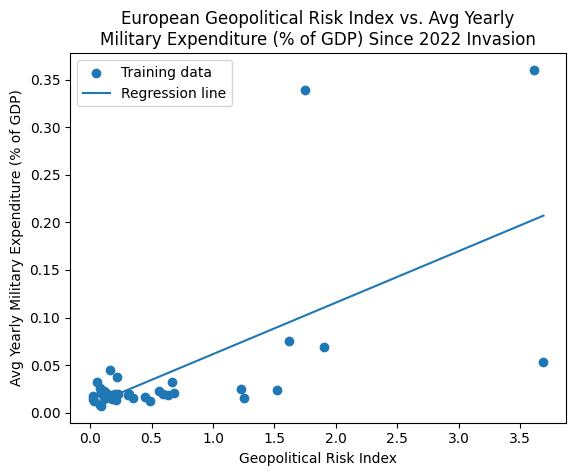

In [8]:
# Plotting the Linear Regression Model

x_line = pd.DataFrame({
    "avg_gpr_index": np.linspace(
        X["avg_gpr_index"].min(),
        X["avg_gpr_index"].max(),
        100
    )
})

y_line = model.predict(x_line)

plt.scatter(X_train, y_train, label="Training data")
plt.plot(x_line["avg_gpr_index"], y_line, label="Regression line")
plt.xlabel("Geopolitical Risk Index")
plt.ylabel("Avg Yearly Military Expenditure (% of GDP)")
plt.title("European Geopolitical Risk Index vs. Avg Yearly\n"
          "Military Expenditure (% of GDP) Since 2022 Invasion")

plt.legend()
plt.show()

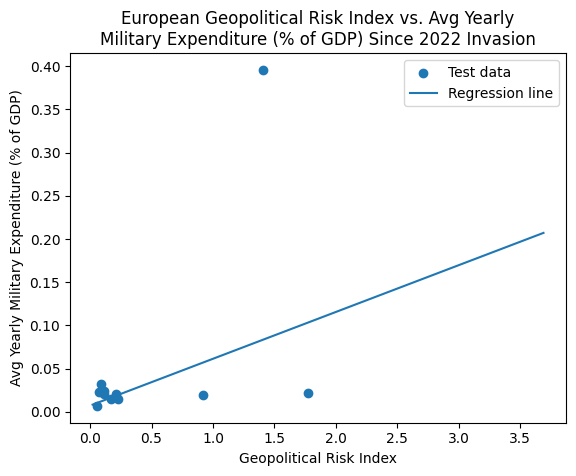

In [10]:
# Plotting the test data

x_line = pd.DataFrame({
    "avg_gpr_index": np.linspace(
        X["avg_gpr_index"].min(),
        X["avg_gpr_index"].max(),
        100
    )
})

y_line = model.predict(x_line)

plt.scatter(X_test, y_test, label="Test data")
plt.plot(x_line["avg_gpr_index"], y_line, label="Regression line")
plt.xlabel("Geopolitical Risk Index")
plt.ylabel("Avg Yearly Military Expenditure (% of GDP)")
plt.title("European Geopolitical Risk Index vs. Avg Yearly\n"
          "Military Expenditure (% of GDP) Since 2022 Invasion")

plt.legend()
plt.show()